In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import GridSpec
import matplotlib.gridspec as gridspec
import glob
import pandas as pd
import math
from math import sqrt
import random
import scipy
from scipy.stats import mannwhitneyu
import seaborn as sns

plt.style.use('styleNB.mplstyle')

wt = 'dHL60KW'
ko = 'dHL60TMEM154KO'
res = 'dHL60TMEM154KO-clone1galvanin-GFP-HA'

E_levels = [0, 1, 3]

# markers for different E_field strengths 
# when plotting for a single cell type
marker_dict = {
    0: 'o',
    1: 's',
    3: 'D'
}

def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
        d_ = d_.copy().sort_values('frame')
        interval_frames = d_.frame.values[::frame_step]
        sampled = d_[d_['frame'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    df_out['interval'] = df_out['frame']

    return df_out

##########################
# colors for each cell type

# celllines = df.celltype.unique() 
# colors = sns.color_palette("tab10")
# color_dict = dict(zip(df.celltype.unique(), colors))    
# color_dict.update({'dHL60KW':'#B8BABC'})

color_dict = {'dHL60KW': '#B8BABC',
             'dHL60TMEM154KO': (1.0, 0.4980392156862745, 0.054901960784313725),
             'dHL60TMEM154KO-clone1galvanin-GFP-HA': (0.17254901960784313,
              0.6274509803921569,
              0.17254901960784313)}


# Figure 2 Related

### Load in data and perform general filter (remove short trajectories, non-motile cells, and cells likely on the top or bottom of side (ie not migrating in 3D)

In [34]:
# Load data

f_compiled = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_tracking.csv'

df = pd.read_csv(f_compiled)
df = df[['cell', 'frame', 'x', 'y', 'z', 'celltype', 'E_V_cm',
       'date', 'trial', 'user']]
df = df[df.celltype != 'dHL60TMEM154KO-clone1galvanin-GFP-HA']

f_rescue_filtered = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_rescue_tracking_GFPplus.csv'
df_gfp = pd.read_csv(f_rescue_filtered)
df_gfp = df_gfp[['cell', 'frame', 'x', 'y', 'z',
       'celltype', 'E_V_cm', 'date', 'trial', 'user']]


df = pd.concat([df, df_gfp], ignore_index = True)

df = df.replace('dHL60TMEM154KO-clone1', 'dHL60TMEM154KO')
df = df.replace('dHL60TMEM154KO-clone12', 'dHL60TMEM154KO')

#############################
# Step 1: Remove cells at the periphery
#############################
df_temp_ = pd.DataFrame()
for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df = df_temp_

#############################
# Step 2: Filter trajectories
#############################
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 20:
        continue

    if d_.E_V_cm.unique() not in E_levels:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0], row.z.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Filter: skip low-displacement tracks
    total_movement = np.sum(np.linalg.norm(np.diff(positions[:, :2], axis=0), axis=1))
    if total_movement < 15:
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1],
            'z': positions[:, 2]
        })
    ], ignore_index=True)


# Step 3: subsample every three minutes
df_intervals_3 = parse_trajectories(df_filtered_tracks, frame_step=3)

# Compass Autocorrelation

In [42]:
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr

# generate autocorrelation list (compass autocorrelation for each trajectory
autocorr_list = []
for g, d in df_intervals_3.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * 3,  # actual lag in frames
        'autocorr': acf
    }))
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

# Calculate average for each time lag
df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()

     metric  E_V_cm                              celltype  n_test  n_control  \
0  autocorr       0                        dHL60TMEM154KO    1026        614   
1  autocorr       0  dHL60TMEM154KO-clone1galvanin-GFP-HA     769        614   
2  autocorr       1                        dHL60TMEM154KO    1131        779   
3  autocorr       1  dHL60TMEM154KO-clone1galvanin-GFP-HA     666        779   
4  autocorr       3                        dHL60TMEM154KO     976        538   
5  autocorr       3  dHL60TMEM154KO-clone1galvanin-GFP-HA     449        538   

   median_test  median_control       p_value  
0    -0.072368        0.028684  2.218611e-02  
1    -0.068033        0.028684  5.477356e-02  
2     0.018395        0.111306  2.789722e-03  
3     0.213513        0.111306  2.365543e-02  
4     0.115199        0.471758  1.586157e-17  
5     0.490543        0.471758  1.342543e-01  


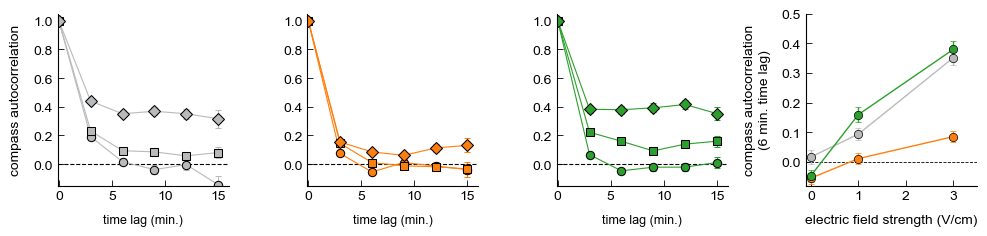

In [43]:
# Choose lag of interest (in minutes)
lag_of_interest = 6
df_lag = df_autocorr[df_autocorr.lag == lag_of_interest]

# Stats for bar plot
df_lag_stats = df_lag.groupby(['celltype', 'E_V_cm']).agg(
    mean_acf=('autocorr', 'mean'),
    sem_acf=('autocorr', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

# Unique celltypes
celltypes = df_avg_autocorr.celltype.unique()
n_celltypes = len(celltypes)

# Create figure with N+1 subplots in a row
fig, axes = plt.subplots(1, n_celltypes + 1, figsize=(2.5 * (n_celltypes + 1), 2.5))

# Time series autocorrelation plots (left side)
for ax, celltype in zip(axes[:-1], celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype == celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})",
            capsize=2,
            marker=marker_dict.get(e, 'o'),
            markersize=6,
            linewidth=0.8,
            color=color_dict.get(celltype, 'gray'),
            markeredgecolor='k',
            markeredgewidth=0.75
        )
    ax.set_xlim(-0.1, 5 * 3 + 1)
    ax.set_ylim(-0.15, 1.05)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel('time lag (min.)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(False)

axes[0].set_ylabel('compass autocorrelation', fontsize=10)

# Plot for fixed lag (rightmost column)
for celltype, d in df_lag_stats.groupby('celltype'):
     axes[-1].errorbar(
        d['E_V_cm'], d['mean_acf'], yerr=d['sem_acf'],
        label=celltype,
        lw=1, marker='o', markersize=6,
        color=color_dict.get(celltype, None),
        zorder=10, capsize=2,
         markeredgecolor='k',
            markeredgewidth=0.5
    )

axes[-1].axhline(0, color='k', linestyle='--', zorder=0)
axes[-1].set_xlim(-0.1, 3.5)
axes[-1].set_ylim(-0.08, 0.5)
axes[-1].set_xlabel('electric field strength (V/cm)', fontsize=10)
axes[-1].set_ylabel('compass autocorrelation\n(6 min. time lag)', fontsize=10)
axes[-1].tick_params(labelsize=8)
axes[-1].grid(False)



for ax in axes:
    # Make all visible spines black
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.8)

    # Optionally hide top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set tick color and width
    ax.tick_params(axis='both', colors='black', width=0.6, length=4, labelsize=10)
    
plt.tight_layout()

# plt.savefig('../../figures/Figure2_compassautocorr_updated_.pdf')

#################################
#################################
# Autocorrelation statistics (at one time lag)
#################################
#################################


# Define cell types
celltypes = df_avg_autocorr.celltype.unique()
# Explicitly define groups
test_celltypes = [
         'dHL60TMEM154KO',
       'dHL60TMEM154KO-clone1galvanin-GFP-HA'
]
control_celltype = 'dHL60KW'

def perform_mannwhitney_autocorr(df):
    df_lag6 = df[df['lag'] == 6]  # assuming lag 9 is desired
    results = []
    for ev in sorted(df_lag6['E_V_cm'].unique()):
        for test_ct in test_celltypes:
            group1 = df_lag6[(df_lag6['E_V_cm'] == ev) & (df_lag6['celltype'] == test_ct)]['autocorr'].dropna()
            group2 = df_lag6[(df_lag6['E_V_cm'] == ev) & (df_lag6['celltype'] == control_celltype)]['autocorr'].dropna()
            if len(group1) > 0 and len(group2) > 0:
                stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
                results.append({
                    'E_V_cm': ev,
                    'celltype': test_ct,
                    'control': control_celltype,
                    'statistic': stat,
                    'p_value': p,
                    'metric': 'autocorr',
                    'n_test': len(group1),
                    'n_control': len(group2),
                    'median_test': group1.median(),
                    'median_control': group2.median()
                })
    return pd.DataFrame(results)

df_stats_autocorr = perform_mannwhitney_autocorr(df_autocorr)

# Combine
df_stats_summary = df_stats_autocorr

# Optional: print or export
# print(df_stats_summary)
print(df_stats_summary[['metric', 'E_V_cm', 'celltype', 'n_test', 'n_control', 'median_test', 'median_control', 'p_value']])